# **Felügyelt Gépi Tanulás Projekt**

## **Adatok osztályozása különböző ML módszerek segítségével**

**Feladat**: Spotify alkalmazásban legtöbbet streamelt dalok tempójának meghatározása zenei tulajdonságok alapján (Osztályozás)

Oszlopok nevei és típusai:

1. track_name: A dal neve (string)
2. artist(s)_name: Az előadó(k) neve (string)
3. released_year: A kiadás éve (int64) {Tartomany: 1930-2024}
4. key: A dal hangneme/hangmagassága (string)
5. bpm: A dal tempója (int64) {Tartomány: 0-250}
6. danceability_%: (int64) {Tartomány: 0-100}
7. valence_%: (int64) {Tartomány: 0-100}
8. energy_%: (int64) {Tartomány: 0-100}
9. acousticness_%: (int64) {Tartomány: 0-100}
10. liveness_%: (int64) {Tartomány: 0-100}
11. speechiness_%: (int64) {Tartomány: 0-100}

# Változók vizsgálata

Függő/Magyarázott változó: 
- Tempó: a dal tempója (0-250).

Független/Magyarázó változók: 
- Táncolhatóság (danceability), 
- Pozitivitás (valence),
- Energia (energy),
- Akusztikusság (acousticness),
- Élősség (liveness),
- Beszédiség (speechiness).

Magyarázó változók jelentése:
- Táncolhatóság: a dal alkalmassága táncra (0-100).
- Pozitivitás: a dal tartalmának pozitív hatása a hallgatóra (0-100).
- Energia: a dal érzékelt energiaszintje (0-100).
- Akusztikusság: akusztikus elemek jelenléte a dalban (0-100).
- Élősség: élő elemek jelenléte a dalban (0-100).
- Beszédiség: elhangzott szavak aránya a dalban (0-100).


# Könyvtárak és adatok betöltése

In [2]:
import pandas as pd
import numpy as np
import graphviz as gv

from fitter import Fitter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from scipy.stats import mode

from sklearn.ensemble import RandomForestClassifier

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.tree import export_graphviz

from IPython.display import Image


data=pd.read_csv('spotify.csv')
data.head(10)

,track_name,artist(s)_name,released_year,key,bpm,danceability_%,valence_%,energy_%,acousticness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2023,B Major,125,80,89,83,31,8,4
1,LALA,Myke Towers,2023,C# Major,92,71,61,74,7,10,4
2,vampire,Olivia Rodrigo,2023,F Major,138,51,32,53,17,31,6
3,Cruel Summer,Taylor Swift,2019,A Major,170,55,58,72,11,11,15
4,WHERE SHE GOES,Bad Bunny,2023,A Minor,144,65,23,80,14,11,6
5,Sprinter,"Dave, Central Cee",2023,C# Major,141,92,66,58,19,8,24
6,Ella Baila Sola,"Eslabon Armado, Peso Pluma",2023,F Minor,148,67,83,76,48,8,3
7,Columbia,Quevedo,2023,F Major,100,67,26,71,37,11,4
8,fukumean,Gunna,2023,C# Minor,130,85,22,62,12,28,9
9,La Bebe - Remix,"Peso Pluma, Yng Lvcas",2023,D Minor,170,81,56,48,21,8,33


# Adathalmaz előkészítése az osztályozáshoz

**Felesleges oszlopok elhagyása**

In [3]:
data.drop(labels="track_name", axis=1, inplace=True)
data.drop(labels="artist(s)_name", axis=1, inplace=True)
data.drop(labels="released_year", axis=1, inplace=True)
data.drop(labels="key", axis=1, inplace=True)

data.head(10)

,bpm,danceability_%,valence_%,energy_%,acousticness_%,liveness_%,speechiness_%
0,125,80,89,83,31,8,4
1,92,71,61,74,7,10,4
2,138,51,32,53,17,31,6
3,170,55,58,72,11,11,15
4,144,65,23,80,14,11,6
5,141,92,66,58,19,8,24
6,148,67,83,76,48,8,3
7,100,67,26,71,37,11,4
8,130,85,22,62,12,28,9
9,170,81,56,48,21,8,33


**A *bpm* folytonos változó kategorizálása**

In [4]:
def categorize_bpm(bpm):
    if bpm < 90:
        return "very slow"
    elif bpm < 110:
        return "slow"
    elif bpm < 130:
        return "normal"
    elif bpm < 150:
        return "fast"
    else:
        return "very fast"

data['bpm']=data['bpm'].apply(categorize_bpm)

data.head(10)

,bpm,danceability_%,valence_%,energy_%,acousticness_%,liveness_%,speechiness_%
0,normal,80,89,83,31,8,4
1,slow,71,61,74,7,10,4
2,fast,51,32,53,17,31,6
3,very fast,55,58,72,11,11,15
4,fast,65,23,80,14,11,6
5,fast,92,66,58,19,8,24
6,fast,67,83,76,48,8,3
7,slow,67,26,71,37,11,4
8,fast,85,22,62,12,28,9
9,very fast,81,56,48,21,8,33


**Magyarázó változók leíró statisztikáinak elemzése**

,Minimum,Maximum,Range,Mean,Std Dev,Median
danceability_%,23,96,73,66.969570,14.630610,69.0
valence_%,4,97,93,51.431270,23.480632,51.0
energy_%,9,97,88,64.279119,16.550526,66.0
acousticness_%,0,97,97,27.057712,25.996077,18.0
liveness_%,3,97,94,18.213012,13.711223,12.0
speechiness_%,2,64,62,10.131165,9.912888,6.0


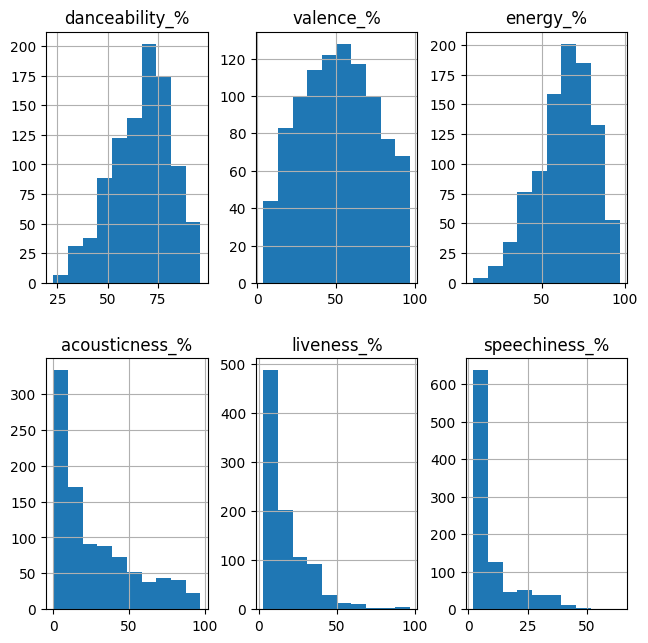

In [5]:
data2=data.iloc[:,1:].copy()
df=pd.DataFrame(data2)
summary = pd.DataFrame({
    'Minimum': df.min(),
    'Maximum': df.max(),
    'Range': df.max()-df.min(),
    'Mean': df.mean(),
    'Std Dev': df.std(),
    'Median': df.median(),
})

df.hist(figsize=(7.5,7.5),layout=(2,3))
summary

**Magyarázó változók közötti korrelációs együtthatók kiszámítása**

In [6]:
korr=data.iloc[:,1:].copy()
korr.corr()

,danceability_%,valence_%,energy_%,acousticness_%,liveness_%,speechiness_%
danceability_%,1.000000,0.408451,0.198095,-0.236165,-0.077538,0.184977
valence_%,0.408451,1.000000,0.357612,-0.081907,0.021278,0.041081
energy_%,0.198095,0.357612,1.000000,-0.577344,0.117302,-0.004846
acousticness_%,-0.236165,-0.081907,-0.577344,1.000000,-0.050142,-0.022501
liveness_%,-0.077538,0.021278,0.117302,-0.050142,1.000000,-0.022525
speechiness_%,0.184977,0.041081,-0.004846,-0.022501,-0.022525,1.000000


A korrelációs együttható nem túl magas vagy alacsony egyik változó kombinációnál sem, így nem érdemes elhagynunk további változókat!

**Osztálycímkének választott változó és prediktív változók meghatározása**

In [7]:
classlabel=list(data.columns[:1])
features=list(data.columns[1:])

print("Osztálycímke:",classlabel)
print("Leíró változók:",features)

Osztálycímke: ['bpm']
Leíró változók: ['danceability_%', 'valence_%', 'energy_%', 'acousticness_%', 'liveness_%', 'speechiness_%']


**Bemeneti/magyarázó változók (X) és kimeneti/magyarázott változó (y) tömbösítése**

In [8]:
X=data.iloc[:,1:].values
y=data.iloc[:,:1].values.reshape(-1,1)
print(X)
print("")
y[:15]

[[80 89 83 31  8  4]
 [71 61 74  7 10  4]
 [51 32 53 17 31  6]
 ...
 [80 81 67  4  8  6]
 [82 67 77  8 12  5]
 [61 32 67 15 11  5]]



array([['normal'],
       ['slow'],
       ['fast'],
       ['very fast'],
       ['fast'],
       ['fast'],
       ['fast'],
       ['slow'],
       ['fast'],
       ['very fast'],
       ['very slow'],
       ['very fast'],
       ['normal'],
       ['fast'],
       ['very fast']], dtype=object)

**Adatok tréning és teszt halmazokra való felbontása (80%-20%) és standardizálás**

In [9]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
y_test[:15]

array([['slow'],
       ['very slow'],
       ['very slow'],
       ['normal'],
       ['fast'],
       ['normal'],
       ['very fast'],
       ['normal'],
       ['normal'],
       ['very fast'],
       ['slow'],
       ['normal'],
       ['normal'],
       ['very slow'],
       ['fast']], dtype=object)

# Döntési Fa osztályozó alkalmazása

**Modell létrehozása, tanítása és alkalmazása**

In [10]:
clf_dtree = DecisionTreeClassifier()
clf_dtree=clf_dtree.fit(X_train,y_train)
y_pred_dtree=clf_dtree.predict(X_test)
y_pred_dtree.reshape(-1,1)[:15]

array([['slow'],
       ['fast'],
       ['very fast'],
       ['very fast'],
       ['very fast'],
       ['fast'],
       ['normal'],
       ['normal'],
       ['slow'],
       ['normal'],
       ['fast'],
       ['slow'],
       ['slow'],
       ['very fast'],
       ['normal']], dtype=object)

**Paraméter nélküli döntési fa értékelése**

In [11]:
print("Paraméter nélküli pontosság:",clf_dtree.score(X_test,y_test))
print("")
print(classification_report(y_test,y_pred_dtree))

Paraméter nélküli pontosság: 0.2670157068062827

              precision    recall  f1-score   support

        fast       0.18      0.20      0.19        41
      normal       0.28      0.31      0.30        48
        slow       0.35      0.37      0.36        49
   very fast       0.27      0.27      0.27        33
   very slow       0.11      0.05      0.07        20

    accuracy                           0.27       191
   macro avg       0.24      0.24      0.24       191
weighted avg       0.26      0.27      0.26       191



**Keveredési mátrix meghatározása**

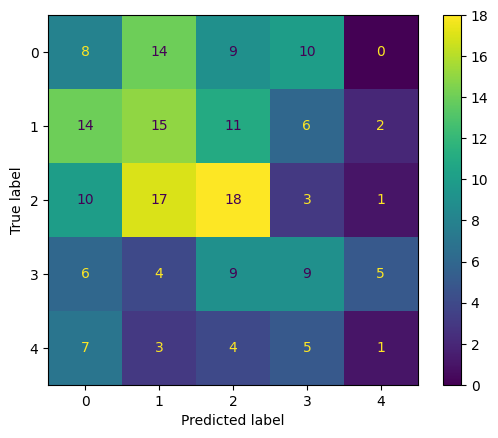

In [12]:
cm_dtree=confusion_matrix(y_test,y_pred_dtree)
disp=ConfusionMatrixDisplay(confusion_matrix=cm_dtree)
disp.plot()

**Döntési fa paraméterezése**

In [13]:
clf_dtree2=DecisionTreeClassifier(criterion="gini",max_depth=5,min_samples_split=10)
clf_dtree2=clf_dtree2.fit(X_train,y_train)

**Paraméteres döntési fa értékelése**

In [14]:
print("Paraméteres pontosság:",clf_dtree2.score(X_test, y_test))

Paraméteres pontosság: 0.36649214659685864


**Döntési fa ábrázolása GraphViz modul segítségével**

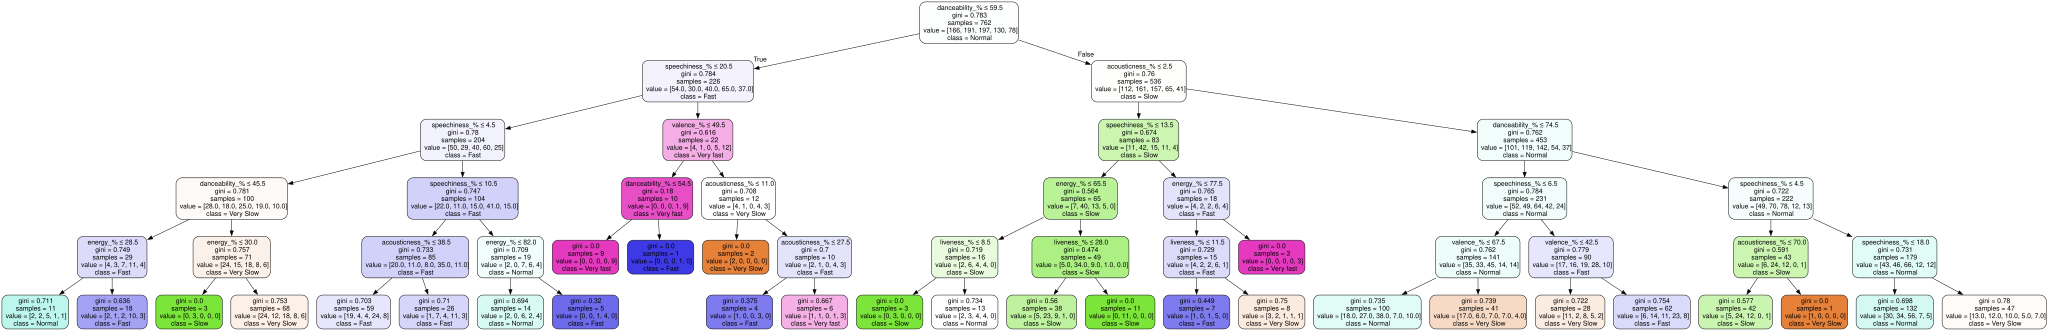

In [15]:
dot_data=export_graphviz(clf_dtree2,out_file=None,
                      feature_names=features,
                      class_names=["Very Slow","Slow","Normal","Fast","Very fast"],
                      filled=True,
                      rounded=True,
                      special_characters=True)
graph=gv.Source(dot_data)
graph

# Random Forest osztályozó alkalmazása

**Modell létrehozása, tanítása és alkalmazása**

In [16]:
clf_rfc=RandomForestClassifier()
clf_rfc=clf_rfc.fit(X_train,y_train.ravel())
y_pred_rfc = clf_rfc.predict(X_test)
y_pred_rfc.reshape(-1,1)[:15]

array([['slow'],
       ['very fast'],
       ['very fast'],
       ['slow'],
       ['slow'],
       ['very fast'],
       ['normal'],
       ['normal'],
       ['normal'],
       ['slow'],
       ['fast'],
       ['slow'],
       ['very fast'],
       ['very slow'],
       ['fast']], dtype=object)

**Paraméter nélküli kiértékelés**

In [17]:
print("A modell pontossága:",clf_rfc.score(X_test,y_test))

A modell pontossága: 0.31413612565445026


**Keveredési mátrix meghatározása**

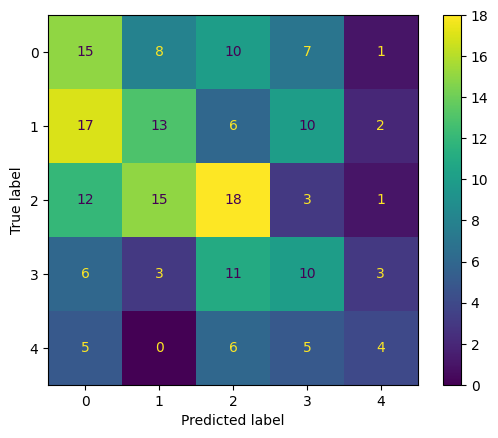

In [18]:
cm_rfc=confusion_matrix(y_test,y_pred_rfc)
disp=ConfusionMatrixDisplay(confusion_matrix=cm_rfc)
disp.plot()

**Paraméterezés (különböző paraméter kombinációkkal)**

In [19]:
clf_rfc2 = RandomForestClassifier(random_state=0,
                                  n_estimators=200,
                                  max_depth=2,
                                  criterion='entropy',
                                  min_samples_leaf=15)
clf_rfc2=clf_rfc2.fit(X_train,y_train.ravel())

clf_rfc3 = RandomForestClassifier(random_state=1,
                                  n_estimators=150,
                                  max_depth=3,
                                  criterion='entropy',
                                  min_samples_leaf=17)
clf_rfc3=clf_rfc3.fit(X_train, y_train.ravel())

clf_rfc4 = RandomForestClassifier(random_state=1,
                                  n_estimators=175,
                                  max_depth=3,
                                  criterion='entropy',
                                  min_samples_leaf=50)
clf_rfc4=clf_rfc4.fit(X_train, y_train.ravel())

**Paraméteres kiértékelés**

In [20]:
print(clf_rfc2.score(X_test,y_test))
print(clf_rfc3.score(X_test,y_test))
print(clf_rfc4.score(X_test,y_test))

0.2931937172774869
0.3036649214659686
0.33507853403141363


**Eredmény ábrázolása (a kapott erdő egyik fája) a GraphViz modul segítségével**

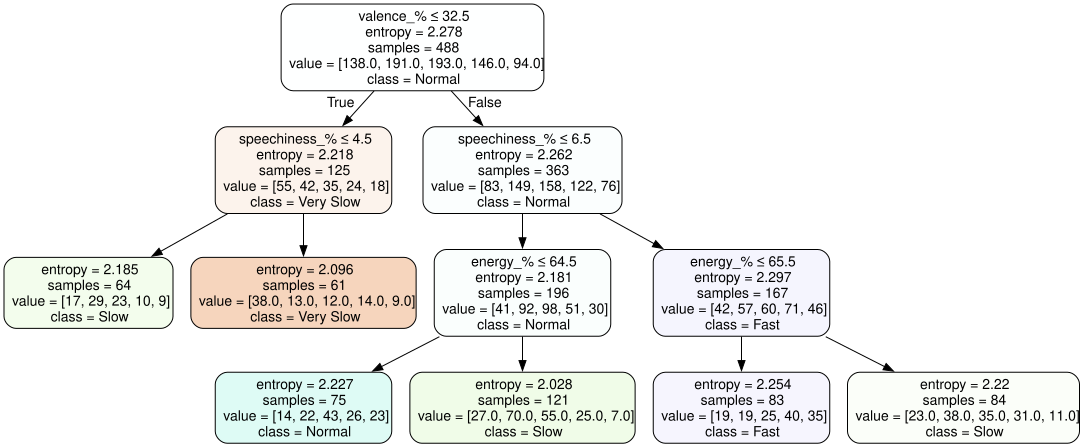

In [21]:
tree=clf_rfc4.estimators_[0]
dot_data2=export_graphviz(tree,out_file=None,
                      feature_names=features,
                      class_names=["Very Slow","Slow","Normal","Fast","Very fast"],
                      filled=True,
                      rounded=True,
                      special_characters=True)
graph2=gv.Source(dot_data2)
graph2

# Végső Pontosságok:

- Paraméter nélküli Döntési Fa: 0.2565
- Paraméteres Döntési Fa: 0.2984
- Paraméter nélküli Random Forest: 0.3665
- Paraméteres Random Forest: 0.3822

**Hat helyett négy magyarázó változó használata (Döntési Fa Módszer)**

In [22]:
data.drop(labels="danceability_%",axis=1,inplace=True)
data.drop(labels="speechiness_%",axis=1,inplace=True)
data.head(10)

classlabel=list(data.columns[:1])
features=list(data.columns[1:])

print("Osztálycímke:",classlabel)
print("Leíró változók:",features)

X=data.iloc[:,1:].values
y=data.iloc[:,:1].values.reshape(-1,1)

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf_dtree = DecisionTreeClassifier()
clf_dtree=clf_dtree.fit(X_train,y_train)
y_pred_dtree=clf_dtree.predict(X_test)

print("Paraméter nélküli pontosság:",clf_dtree.score(X_test,y_test))
print("")
print(classification_report(y_test,y_pred_dtree))

Osztálycímke: ['bpm']
Leíró változók: ['valence_%', 'energy_%', 'acousticness_%', 'liveness_%']
Paraméter nélküli pontosság: 0.2198952879581152

              precision    recall  f1-score   support

        fast       0.17      0.17      0.17        41
      normal       0.23      0.19      0.20        48
        slow       0.29      0.35      0.31        49
   very fast       0.19      0.21      0.20        33
   very slow       0.12      0.10      0.11        20

    accuracy                           0.22       191
   macro avg       0.20      0.20      0.20       191
weighted avg       0.21      0.22      0.22       191

